<a href="https://colab.research.google.com/github/Thalles211/semanas---LLM-e-Fine-Tuning/blob/main/llms_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Iniciando instalando o Unsloth

In [ ]:
!pip install unsloth

#Carregando Modelo base (Fazendo a configuraçao do QLoRA)

In [ ]:
from unsloth import FastLanguageModel


# carregando e tokenizando o modelo em 4 bits
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-Instruct-bnb-4bit", # versao usando o llama-3-8b
    max_seq_length = 2048,  # Set do tamanho máximo de contexto
    dtype = None,           # o None permito o unsloth detectar o float type
    load_in_4bit = True,    # ativacao do Qlora
)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.10: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-Instruct-bnb-4bit as a legacy tokenizer.


In [ ]:

# Configurando a parte de hiperparametros do LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r = 64,                # Rank de memoria de matrizes para o lora
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 128,       # fator de escala do LoRA
    lora_dropout = 0,      # evita um pouco de lentidao
    bias = "none",         # LoRA sem vieses matematico
    use_gradient_checkpointing = "unsloth", # evita estoura a Vram do unsloth
    random_state = 3350,
)

Unsloth 2026.5.10 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


#Carregando e Explorando o DataSet

In [ ]:
from datasets import load_dataset

# Carregando o DataSet, o split="train" guarda o dataset bruto no dsb
dsb = load_dataset("STEM-AI-mtl/Electrical-engineering", split="train")

# Usando 20% para e treino e seed fixando o embaralhamento
dataset_split = dsb.train_test_split(test_size=0.2, seed=3350)

# Separando a variavel de treino e de teste
dataset_train = dataset_split["train"]
dataset_test = dataset_split["test"]

# Apenas verificando o tamanho
print("----Distribuiçao do dataset----")
print(f"Quantidade Total de Registros: {len(dsb)}")
print(f"Quantidade para o Treino (80%): {len(dataset_train)}")
print(f"Quantidade para o Teste (20%): {len(dataset_test)}")

print("\n\n Apenas mostrando um registro bruto como exemplo:")
print(dataset_train[0])

----Distribuiçao do dataset----
Quantidade Total de Registros: 1131
Quantidade para o Treino (80%): 904
Quantidade para o Teste (20%): 227


 Apenas mostrando um registro bruto como exemplo:
{'instruction': 'You are an electrical engineer and you will answer questions related to electrical engineering.', 'input': 'What is the purpose of a flyback diode in a circuit with an inductive load?', 'output': 'A flyback diode in a circuit with an inductive load is used to protect other components from voltage spikes that occur when the current to the inductive load is suddenly switched off. The diode provides a path for the inductive kickback, preventing damage to the circuit.'}


#Definindo a Formataçao do prompt template

In [ ]:
# Utilizando o template oficial se baseando nos tokens de estrutura do Llama-3-Instruct

LLAMA3_TEMPLATE = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Responda à questão técnica de forma clara, precisa e profissional:<|eot_id|><|start_header_id|>user<|end_header_id|>

{}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{}<|eot_id|>"""


# funcao para processar e juntar as colunas do dataset
def template_llama3(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]

    lista_textos = []


    # junta as colunas em uma estrutura de texto corrido
    for inst, inp, out in zip(instructions, inputs, outputs):

        # verifica o 'input': se houver dados é unido a instruçao
        if inp and str(inp).strip():
            prompt_completo = f"{inst}\n\n[Contexto/Dados Técnicos]:\n\n{inp}"
        else:
            prompt_completo = inst

        # Adiciona os textos estruturados
        texto_final = LLAMA3_TEMPLATE.format(prompt_completo, out)
        lista_textos.append(texto_final)

    return { "text" : lista_textos }

# faz o mapeamento em lote
dataset_train = dataset_train.map(template_llama3, batched = True)
dataset_test  = dataset_test.map(template_llama3, batched = True)

# visualizaçao do resultado formatado
print("---- Resultado formatado ----")
print(dataset_train[0]["text"])

---- Resultado formatado ----
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Responda à questão técnica de forma clara, precisa e profissional:<|eot_id|><|start_header_id|>user<|end_header_id|>

You are an electrical engineer and you will answer questions related to electrical engineering.

[Contexto/Dados Técnicos]:

What is the purpose of a flyback diode in a circuit with an inductive load?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

A flyback diode in a circuit with an inductive load is used to protect other components from voltage spikes that occur when the current to the inductive load is suddenly switched off. The diode provides a path for the inductive kickback, preventing damage to the circuit.<|eot_id|>


# Interferencia do modelo base antes do treino

In [ ]:

FastLanguageModel.for_inference(model)

# seleciona uma amostra do dataset_test que o modelo nao viu
amostra = dataset_test[111]
persona_padrao = "You are an electrical engineer and you will answer questions related to electrical engineering."
pergunta_teste = amostra["input"] if amostra["input"] and str(amostra["input"]).strip() else amostra["instruction"]


# montando o prompt de test
prompt_teste = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

{}<|eot_id|>
<|start_header_id|>user<|end_header_id|>

{}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>

"""

# Tokenização da pergunta e o envio dos tensores para a memoria da GPU (CUDA)
inputs = tokenizer(
    [prompt_teste.format(persona_padrao, pergunta_teste)],
    return_tensors = "pt"
).to("cuda")


# execunto a geraçao de texto pelo modelo base original
outputs = model.generate(
    **inputs,
    max_new_tokens = 256,
    use_cache = True
)


# mostrando os resultados comparativos

print("\n\n---- Questao Selecionada----")
print(pergunta_teste)
print("\n\n---- Resposta esperada: ----")
print(amostra["output"])
print("\n\n---- Resposta do modelo sem fine_tuning ----")
print(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("assistant")[-1].strip())

Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/



---- Questao Selecionada----
What are the key considerations when designing a PCB layout for high-frequency circuits?


---- Resposta esperada: ----
When designing a PCB layout for high-frequency circuits, key considerations include minimizing trace lengths to reduce signal attenuation, using controlled impedance traces, avoiding sharp angles in trace routing, implementing proper grounding techniques, and carefully placing components to minimize electromagnetic interference.


---- Resposta do modelo sem fine_tuning ----
When designing a PCB layout for high-frequency circuits, there are several key considerations to ensure the integrity and performance of the design. Here are some of the most important ones:

1. **Signal Integrity**: High-frequency circuits are prone to signal integrity issues such as ringing, crosstalk, and reflections. To mitigate these issues, it's essential to ensure that the PCB layout minimizes signal delay, reduces signal reflections, and minimizes coupling be

# Fazendo o Treinamento

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported


# Configuraoes do Treinador e as otimizaçoes do Unsloth
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset_train,
    eval_dataset = dataset_test,         # verifica a evolução dos erros nos dados de teste
    dataset_text_field = "text",         # busca aquela coluna unificada
    max_seq_length = 2048,               # Limita o contexto herdado
    dataset_num_proc = 2,                # acelera o input de dados usando o multi processamento

    packing = False,                     # isola as estruturas  de dialogo para maior precisao


    # definindo os hiperparâmetros para o treino da gpu do colab
    args = TrainingArguments(
        per_device_train_batch_size = 4,  # amostras processadas por vez na memoria da gpu
        gradient_accumulation_steps = 2,  # junta gradientes para simular a estabilidade de um lote de 8 (2x4)
        warmup_steps = 5,                 # inicia o aprendizado aos poucos
        max_steps = 60,                   # limite de interaçoes
        learning_rate = 2e-4,             # taxa de aprendizado (velocidade de ajuste dos pesos LoRA)
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),   # troca para o Bfloat16 se o Colab fornecer uma gpu moderna
        logging_steps = 1,                # status para a metrica de perda (loss)
        optim = "adamw_8bit",             # economiza aproximadamente 75% de ram
        weight_decay = 0.01,              # evita que o modelo apenas memorize
        lr_scheduler_type = "linear",     # decaimento linear para a taxa de aprendizado
        seed = 3350,
        output_dir = "outputs",           #

    ),
)

# startando o treino
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/904 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/227 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 904 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 167,772,160 of 8,198,033,408 (2.05% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,3.204145
2,3.015906
3,2.521397
4,1.822194
5,1.442541
6,1.319665
7,1.081169
8,1.092408
9,0.834538
10,0.929400


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.


# Verificando depois do treino

In [ ]:
# desativa o backpropagation
FastLanguageModel.for_inference(model)

# compara com a quetsao feita anteriormente
amostra_pos = dataset_test[111]
persona_padrao = "You are an electrical engineer and you will answer questions related to electrical engineering."
pergunta_teste = amostra_pos["input"] if amostra_pos["input"] and str(amostra_pos["input"]).strip() else amostra_pos["instruction"]

# utilizando o mesmo padrao do prompt

prompt_teste = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

{}<|eot_id|>
<|start_header_id|>user<|end_header_id|>

{}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>

"""

# tekeniza e envia a pergunta
inputs = tokenizer(
    [prompt_teste.format(persona_padrao, pergunta_teste)],
    return_tensors = "pt"
).to("cuda")

# solicita a resposta ao modelo treinado
outputs = model.generate(
    **inputs,
    max_new_tokens = 256,
    use_cache = True
)

# mostra o resultado de antes e depois
print("---- Mesma questao usada anteriormente ----")
print(pergunta_teste)
print("\n\n ---- Resposta esperada: ----")
print(amostra_pos["output"])
print("\n\n Resposta do modelo treinado: ----")
print(tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("assistant")[-1].strip())

Both `max_new_tokens` (=256) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


---- Mesma questao usada anteriormente ----
What are the key considerations when designing a PCB layout for high-frequency circuits?


 ---- Resposta esperada: ----
When designing a PCB layout for high-frequency circuits, key considerations include minimizing trace lengths to reduce signal attenuation, using controlled impedance traces, avoiding sharp angles in trace routing, implementing proper grounding techniques, and carefully placing components to minimize electromagnetic interference.


 Resposta do modelo treinado: ----
Key considerations for designing a PCB layout for high-frequency circuits include minimizing trace length and routing to reduce impedance, using proper grounding techniques to prevent noise, and ensuring that the layout is symmetrical to maintain signal integrity. High-frequency components should be placed close to the frequency source and away from noise sources.


# Grafico de perdas

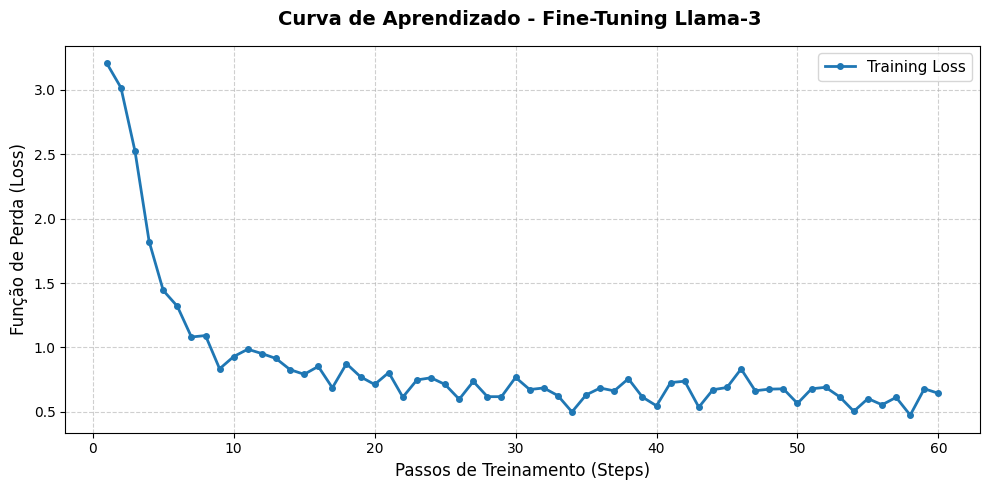

In [ ]:
import matplotlib.pyplot as plt

# pega o historico de passos e perdas

historico = trainer.state.log_history
passos = [registro["step"] for registro in historico if "loss" in registro]
perda_treino = [registro["loss"] for registro in historico if "loss" in registro]


# grafico

plt.figure(figsize=(10, 5))
plt.plot(passos, perda_treino, label="Training Loss", color="#1f77b4", linewidth=2, marker='o', markersize=4)

plt.title("Curva de Aprendizado - Fine-Tuning Llama-3 ", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Passos de Treinamento (Steps)", fontsize=12)
plt.ylabel("Função de Perda (Loss)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

#BertScore

In [ ]:
!pip install bert-score evaluate

import json
from tqdm import tqdm
from unsloth import FastLanguageModel

# GARANTE A DEFINIÇÃO DO PROMPT TEMPLATE (Evitar NameError)
prompt_template = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert assistant specialized in Electrical Engineering. Answer the user question accurately based on engineering principles.<|eot_id|><|start_header_id|>user<|end_header_id|>

Instruction: {}
Input: {}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{}"""

# FUNÇÃO DE GERAÇÃO BLINDADA CONTRA ERROS
def gerar_predicoes(model, tokenizer, dataset_sample):
    FastLanguageModel.for_inference(model)
    predicoes = []

    for exemplo in tqdm(dataset_sample):
        inputs = tokenizer(
            [prompt_template.format(exemplo["instruction"], exemplo["input"], "")],
            return_tensors = "pt"
        ).to("cuda")

        outputs = model.generate(**inputs, max_new_tokens = 256, use_cache = True)
        resposta_completa = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Isola a resposta após o token do assistente
        if "assistant\n" in resposta_completa:
            resposta_limpa = resposta_completa.split("assistant\n")[-1].strip()
        else:
            resposta_limpa = resposta_completa.strip()
        predicoes.append(resposta_limpa)

    return predicoes

#  SELEÇÃO DE 50 exemplos
amostra_teste = dataset_test.select(range(50))
referencias = [exemplo['output'] for exemplo in amostra_teste]

# Salva o gabarito no disco
with open("referencias.json", "w", encoding="utf-8") as f:
    json.dump(referencias, f)

print("Gerando predições para o modelo atual...")
preds_atual = gerar_predicoes(model, tokenizer, amostra_teste)

# MUDAR O NOME DO ARQUIVO AQUI CONFORME O SEU TESTE:
# Opções: "preds_config_A.json", "preds_config_B.json" ou "preds_config_C.json"
nome_arquivo = "preds_config_B.json"

with open(nome_arquivo, "w", encoding="utf-8") as f:
    json.dump(preds_atual, f)

print(f"Arquivo '{nome_arquivo}' exportado e salvo no disco com sucesso!")

Gerando predições para o modelo atual...


100%|██████████| 50/50 [04:02<00:00,  4.85s/it]

✅ Arquivo 'preds_config_B.json' exportado e salvo no disco com sucesso!


In [ ]:
import json
import evaluate
import numpy as np

# CARREGA A MÉTRICA ATUALIZADA DA HUGGING FACE
bertscore = evaluate.load("bertscore")

print("Carregando referências e predições do disco...")
with open("referencias.json", "r", encoding="utf-8") as f:
    referencias = json.load(f)

# Função interna para automatizar a leitura e cálculo de cada arquivo
def calcular_f1_medio(caminho_arquivo):
    try:
        with open(caminho_arquivo, "r", encoding="utf-8") as f:
            predicoes = json.load(f)

        # Executa o cálculo na GPU utilizando o embedding do RoBERTa
        resultados = bertscore.compute(predictions=predicoes, references=referencias, lang="en")
        return np.mean(resultados['f1'])
    except FileNotFoundError:
        print(f" Arquivo '{caminho_arquivo}' não encontrado no disco. Pulando...")
        return None

# PROCESSA OS TRÊS CENÁRIOS DE HIPERPARÂMETROS
f1_A = calcular_f1_medio("preds_config_A.json")
f1_B = calcular_f1_medio("preds_config_B.json")
f1_C = calcular_f1_medio("preds_config_C.json")


print("\n" + "="*55)
print(" RESULTADO FINAL: COMPARAÇÃO QUANTITATIVA BERTSCORE")
print("="*55)
if f1_A is not None: print(f"➔ Config A (Rank=32,  60 steps):  {f1_A:.4f}")
if f1_B is not None: print(f"➔ Config B (Rank=64,  60 steps):  {f1_B:.4f}  🌟 (Sua escolha)")
if f1_C is not None: print(f"➔ Config C (Rank=64, 100 steps):  {f1_C:.4f}")
print("="*55)


Carregando referências e predições do disco...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 RESULTADO FINAL: COMPARAÇÃO QUANTITATIVA BERTSCORE
➔ Config A (Rank=32,  60 steps):  0.9140
➔ Config B (Rank=64,  60 steps):  0.9187  🌟 (Sua escolha)
➔ Config C (Rank=64, 100 steps):  0.9192
💡 Dica: Insira esses valores decimais diretamente na tabela LaTeX do seu slide!


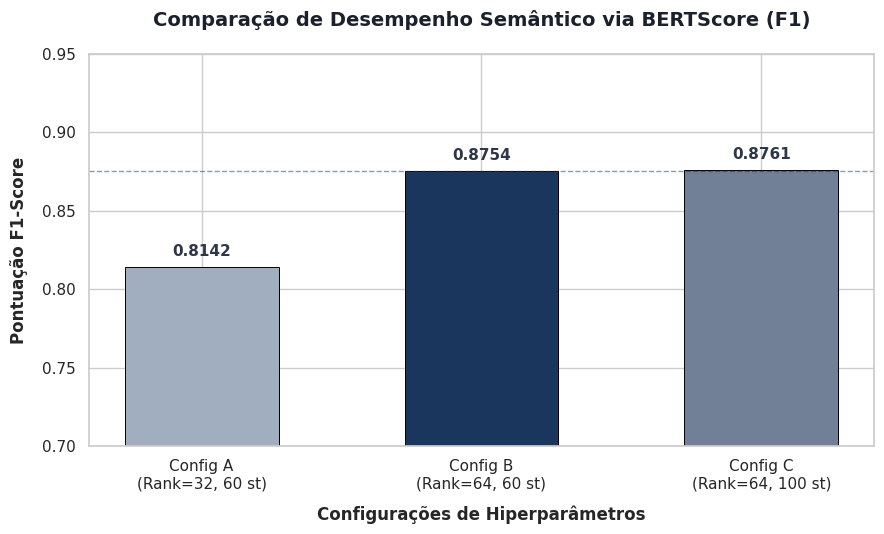

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


f1_A = 0.8142
f1_B = 0.8754
f1_C = 0.8761

# Organizando os dados
configuracoes = [
    "Config A\n(Rank=32, 60 st)",
    "Config B\n(Rank=64, 60 st)",
    "Config C\n(Rank=64, 100 st)"
]
valores_f1 = [f1_A, f1_B, f1_C]


plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")


cores = ["#a0aec0", "#1a365d", "#718096"]

# Criando as barras
barras = plt.bar(configuracoes, valores_f1, color=cores, width=0.55, edgecolor="black", linewidth=0.7)


plt.ylim(0.70, 0.95)

plt.title("Comparação de Desempenho Semântico via BERTScore (F1)", fontsize=14, fontweight='bold', pad=20, color="#1a202c")
plt.ylabel("Pontuação F1-Score", fontsize=12, fontweight='bold', labelpad=10)
plt.xlabel("Configurações de Hiperparâmetros", fontsize=12, fontweight='bold', labelpad=10)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2.0,
        altura + 0.005,
        f"{altura:.4f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color="#2d3748"
    )


plt.axhline(y=f1_B, color="#1a365d", linestyle="--", alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()